# Nucleotide Diversity data processing

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
# import gffutils

%matplotlib inline

In [2]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
#import bioframe as bf
#import bioframe.vis

#### Pandas Viewing Settings

In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### Set matplotlib text export settings for Adobe Illustrator

In [4]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# 5) Import/parse processed H37rv genome annotations

In [5]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GenomeAnno_Genes_DF["Middle"] = (H37Rv_GenomeAnno_Genes_DF["Start"] + H37Rv_GenomeAnno_Genes_DF["End"]) / 2
H37Rv_GenomeAnno_Genes_DF["Length"]  = H37Rv_GenomeAnno_Genes_DF["End"] - H37Rv_GenomeAnno_Genes_DF["Start"]

H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GeneInfo_Subset_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [6]:
H37Rv_GenomeAnno_Genes_DF.head()

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Middle,Length
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,762.0,1524
1,NC_000962.3,2051,3260,+,Rv0002,dnaN,CDS,information pathways,No,DNA polymerase III (beta chain) DnaN (DNA nucl...,NaN,NotExcluded,2655.5,1209
2,NC_000962.3,3279,4437,+,Rv0003,recF,CDS,information pathways,No,DNA replication and repair protein RecF (singl...,NaN,NotExcluded,3858.0,1158
3,NC_000962.3,4433,4997,+,Rv0004,Rv0004,CDS,conserved hypotheticals,No,Conserved hypothetical protein,NaN,NotExcluded,4715.0,564
4,NC_000962.3,5239,7267,+,Rv0005,gyrB,CDS,information pathways,No,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,NaN,NotExcluded,6253.0,2028


In [7]:
# RepoRef_Dir = "../../References"

# H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.WiCtrAndLen.tsv"

# H37Rv_GenomeAnno_Genes_DF["Middle"] = (H37Rv_GenomeAnno_Genes_DF["Start"] + H37Rv_GenomeAnno_Genes_DF["End"]) / 2
# H37Rv_GenomeAnno_Genes_DF["Length"]  = H37Rv_GenomeAnno_Genes_DF["End"] - H37Rv_GenomeAnno_Genes_DF["Start"]

# H37Rv_GenomeAnno_Genes_DF.to_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t", index = False)

## Parse `LowComplexity` and `Low-Mappability` Regions of H37Rv

In [8]:
RepoRef_Dir = "../../References"
Rv_longdust_LCB_OutDir = f"{RepoRef_Dir}/H37Rv_Longdust_LowComplexityRegions"
Rv_LowPupMap_OutDir = f"{RepoRef_Dir}/H37Rv_MappabilityAnalysis_K50E4"

Rv_LowPupmap_K50E4_TSV = f"{Rv_LowPupMap_OutDir}/H37Rv.LowPileupMap.Below1.K50_E4.tsv"
Rv_LowComplexityRegions_TSV = f"{Rv_longdust_LCB_OutDir}/H37Rv.longdust.LCR.relaxedshorter.tsv"


In [9]:
Rv_LowPmap_DF = pd.read_csv(Rv_LowPupmap_K50E4_TSV, sep ="\t")
Rv_LowPmap_DF.shape

(1092, 5)

In [10]:
Rv_LowPmap_DF.head(3)

,chrom,start,end,Length,Overlap_Genes
0,NC_000962.3,23172,23237,65,pstP
1,NC_000962.3,79498,79573,75,Rv0071
2,NC_000962.3,80180,80379,199,Rv0071


In [11]:
Rv_LCRs_DF = pd.read_csv(Rv_LowComplexityRegions_TSV, sep ="\t")
Rv_LCRs_DF.shape

(231, 5)

In [12]:
Rv_LowPmap_DF["Length"].sum()

189147

In [13]:
Rv_LCRs_DF["Length"].sum()

127160

## Define paths to H37Rv PLC genome masking scheme

In [14]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"

PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


## Read in annotated windows of the H37Rv genome

In [15]:
RepoRef_Dir = "../../References"

H37Rv_Windows_Dir = f"{RepoRef_Dir}/H37Rv_GenomeWindows"

H37Rv_1kb_Win_Anno_TSV = f"{H37Rv_Windows_Dir}/H37Rv.1000bp.Windows.Anno.tsv"

H37Rv_1kb_Win_DF = pd.read_csv(H37Rv_1kb_Win_Anno_TSV, sep = "\t")
Rv_1kb_Window_Start_To_Genes_Dict = dict(H37Rv_1kb_Win_DF[['Start', 'Overlap_Genes']].values)


In [16]:
H37Rv_1kb_Win_DF.head(1)

,Chrom,Start,End,Overlap_Genes,Middle
0,NC_000962.3,0,1000,dnaA,500.0


In [17]:
H37Rv_1kb_Win_DF.tail(96).head(3)

,Chrom,Start,End,Overlap_Genes,Middle
4316,NC_000962.3,4316000,4317000,Rv3843c,4316500.0
4317,NC_000962.3,4317000,4318000,_,4317500.0
4318,NC_000962.3,4318000,4319000,Rv3844,4318500.0


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [18]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"



### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [19]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                           sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [20]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                               sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [21]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [22]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [23]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [24]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [25]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [26]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

### Parse in HomologyMap Alignment Variants DFs

In [27]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [28]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [29]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


# Parse `Mtb151CI` Isolate Metadata

In [30]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [31]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [32]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  

SampleID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
SampleID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
SampleID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [33]:
WGA151CI_OrderOfSampleIDs_Phylo = ['N0153', 'N0072', 'mada_2-46', 'mada_1-44', 'mada_107', 'mada_1-1', 'mada_1-51',
                          'mada_1-39', 'mada_1-36', 'mada_117', 'mada_122', 'mada_118', 'mada_1-10', 'R27252',
                          'R23887', 'TB3091', '9050-05', '3003-06', '702-06', '696-05', '8651-04', 'TB3396',
                          '4549-04', 'TB1612', 'TB2780', 'TB3368', 'TB1236', 'TB2659', '8129-04', 'R30215',
                          'R25048', 'TB2512', 'TB2981', 'TB2995', 'TB3113', '706-05', 'R30078', 'R28012',
                          'R27657', 'R30234', 'R31095', 'R28703', 'R24120', 'R36431', 'R29816', 'S0070-08',
                          'N0155', 'N0145', 'R29598', 'R24100', 'S0107-01', 'R28581', 'S0256-08', 'S0085-01',
                          'S0089-01', 'mada_1-11', 'M0003941_3', 'mada_115', 'mada_2-42', 'R37765', '18_0621851',
                          'R22601', 'R27937', 'R18040', 'R18043', 'R27725', 'R26791', 'R20574', 'R20260', 'R21408',
                          'R23146', 'R28980', 'R32929', 'R26778', 'R30420', 'R21893', 'QC-9', 'QC-5', 'QC-3', 'N0004',
                          'mada_1-30', 'N0054', 'N1274', '01_R1134', 'TB2968', 'mada_1-53', 'mada_2-53', 'mada_1-50',
                          'mada_2-1', 'R23571', 'mada_123', 'mada_1-12', 'mada_1-15', 'mada_128', 'mada_1-38', 'TB3054',
                          'mada_126', 'mada_120', 'TB4620', 'M0016737_0', 'M0016395_7', 'R15311', 'TB2661', 'TB3386',
                          'TB3162', '02_R1179', 'M0010874_7', 'QC-7', 'QC-6', 'QC-1', '01_R1430', 'M0011368_9',
                          '02_R1896', 'mada_2-25', 'TB3237', 'mada_103', 'mada_112', 'mada_124', 'S0123-01', 'S0262-02',
                          'TB3251', 'M0017522_5', 'R30396', 'R20896', 'mada_1-32', 'S0106-01', 'R21839', 'R21363', 'R21770',
                          'MT_0080', 'mada_102', 'TB3334', 'M0014888_3', 'mada_151', 'TB3169', 'mada_105', 'QC-8', 'QC-10',
                          'QC-4', 'mada_129', 'mada_139', '02_R1708', '02_R0894', 'mada_2-31', 'mada_1-41', 'N1272', 'N1176',
                          'N1202', 'N0091', 'N1177', 'RW-TB008']


# Define directories to assembly + analysis pipeline (SMK)

In [34]:
### Define directories to PMP-SM (PacBio assembly and analysis pipeline)

### Define varaint calling pipeline output directories

Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects"

Mtb_WGA_SMK_Outputs_Dir = Project_Dir + "/Mtb-WGA-SMK-Output"

WGA151CI_SMK_OutputDir = Mtb_WGA_SMK_Outputs_Dir + "/231121_MtbSetV3_151CI"


In [35]:
#!ls -1 $Mtb_WGA_SMK_Outputs_Dir

In [36]:
#!ls -alh $WGA151CI_SMK_OutputDir | tail -n 14 

### Define output dirs of pipeline

In [37]:
target_OutputDir = WGA151CI_SMK_OutputDir

i_Phylogeny_Dir = f"{target_OutputDir}/Phylogenies"

i_Asm_MergeVar_mpileup_Dir = f"{target_OutputDir}/Asm_MergeVar_mpileup"


i_NucDiv_Dir = f"{target_OutputDir}/NucDiversity"
i_NucDiv_mpileup_Dir = f"{i_NucDiv_Dir}/NucDiv_SNVs_mpileup" 

i_Recomb_Dir = f"{target_OutputDir}/RecombDetection"
i_Gubbins_mpileup_Dir = f"{i_Recomb_Dir}/Gubbins_mpileup_SNVs"

In [38]:
#!ls -alh $target_OutputDir/

In [39]:
!ls -alh $target_OutputDir/Asm_MergeVar_mpileup

total 166M
drwxrwsr-x 2 mm774 hpc_farhat 4.0K Dec  2  2023 .
drwxrwsr-x 2 mm774 hpc_farhat 4.0K Nov 25  2024 ..
-rw-rw-r-- 1 mm774 hpc_farhat 464K Nov 24  2023 AllSNPpositions.MM2.mpileup.SNPs.Union.AllSamples.tsv
-rw-rw-r-- 1 mm774 hpc_farhat 3.4M Nov 24  2023 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.min-100.fasta
-rw-rw-r-- 1 mm774 hpc_farhat 3.4M Nov 24  2023 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.min-100.phy
-rw-rw-r-- 1 mm774 hpc_farhat 176K Nov 24  2023 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.positions
-rw-rw-r-- 1 mm774 hpc_farhat  37M Nov 24  2023 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.vcf
-rw-rw-r-- 1 mm774 hpc_farhat 531K Nov 24  2023 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.vcf.gz
-rw-rw-r-- 1 mm774 hpc_farhat 2.8K Nov 24  2023 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.vcf.gz.tbi
-rw-rw-r-- 1 mm774 hpc_farhat 3.5M Nov 24  2023 MM2.mpileup.call.Merged.SNVs.min-100.fasta
-rw-rw-r-- 1 mm774 hpc_farhat 3.5M Nov 24  2023 MM2.mpileup.c

In [40]:
!ls -alh $i_NucDiv_mpileup_Dir

total 177K
drwxrwsr-x 2 mm774 hpc_farhat 4.0K Nov 30  2023 .
drwxrwsr-x 2 mm774 hpc_farhat 4.0K Nov 30  2023 ..
-rw-rw-r-- 1 mm774 hpc_farhat 177K Nov 30  2023 MM2.mpileup.call.Merged.SNVs.NucDiv.1000bp.windowed.pi


In [41]:
!head -n 5 $i_NucDiv_mpileup_Dir/MM2.mpileup.call.Merged.SNVs.NucDiv.1000bp.windowed.pi

CHROM	BIN_START	BIN_END	N_VARIANTS	PI
NC_000962.3	1	1000	8	0.000217905
NC_000962.3	1001	2000	14	0.000790654
NC_000962.3	2001	3000	3	0.00030556
NC_000962.3	3001	4000	8	0.000221073


In [42]:
#!STOP!!!!!!!

# 1) Define relevant PATHS and target directories

In [43]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

input_SampleNames = SampleIDs_151CI_SOI

# Gubbins_OutPrefix = "Gubbins"

!mkdir $Main_Project_Dir

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

!mkdir $Target_Output_Dir

input_SampleNames = SampleIDs_151CI_SOI


mkdir: cannot create directory ‘/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10’: File exists
mkdir: cannot create directory ‘/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10’: File exists


In [44]:
!ls -alh $Target_Output_Dir

total 52M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:36 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec 13 18:36 ..
-rw-r--r-- 1 mm774 hpc_farhat 6.4M Dec  9 10:35 250201.WGA151CI.V10.MergedVCF.SNVs.lineage1.vcf
-rw-r--r-- 1 mm774 hpc_farhat  17M Dec  9 10:35 250201.WGA151CI.V10.MergedVCF.SNVs.lineage2.vcf
-rw-r--r-- 1 mm774 hpc_farhat 4.6M Dec  9 10:36 250201.WGA151CI.V10.MergedVCF.SNVs.lineage3.vcf
-rw-r--r-- 1 mm774 hpc_farhat  18M Dec  9 10:36 250201.WGA151CI.V10.MergedVCF.SNVs.lineage4.vcf
-rw-r--r-- 1 mm774 hpc_farhat 3.4M Dec  9 10:36 250201.WGA151CI.V10.MergedVCF.SNVs.lineage5.vcf
-rw-r--r-- 1 mm774 hpc_farhat 3.6M Dec  9 10:36 250201.WGA151CI.V10.MergedVCF.SNVs.lineage6.vcf
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:32 Asm_MergeVar_mpileup
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec 12 11:38 Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:32 NucDiv_SNVs_mpileup
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec 14 20:56 RecombEvent-To-HmRegion-C

## Copy NucDiversity output directory (From SMK pipeline output) to analysis directory

In [45]:
!cp -r $i_NucDiv_mpileup_Dir/ $Target_Output_Dir/

In [46]:
!cp -r $i_Asm_MergeVar_mpileup_Dir/ $Target_Output_Dir/

In [47]:
print(Target_Output_Dir)

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10


In [48]:
!ls -alh $Target_Output_Dir

total 52M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:36 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec 13 18:36 ..
-rw-r--r-- 1 mm774 hpc_farhat 6.4M Dec  9 10:35 250201.WGA151CI.V10.MergedVCF.SNVs.lineage1.vcf
-rw-r--r-- 1 mm774 hpc_farhat  17M Dec  9 10:35 250201.WGA151CI.V10.MergedVCF.SNVs.lineage2.vcf
-rw-r--r-- 1 mm774 hpc_farhat 4.6M Dec  9 10:36 250201.WGA151CI.V10.MergedVCF.SNVs.lineage3.vcf
-rw-r--r-- 1 mm774 hpc_farhat  18M Dec  9 10:36 250201.WGA151CI.V10.MergedVCF.SNVs.lineage4.vcf
-rw-r--r-- 1 mm774 hpc_farhat 3.4M Dec  9 10:36 250201.WGA151CI.V10.MergedVCF.SNVs.lineage5.vcf
-rw-r--r-- 1 mm774 hpc_farhat 3.6M Dec  9 10:36 250201.WGA151CI.V10.MergedVCF.SNVs.lineage6.vcf
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:32 Asm_MergeVar_mpileup
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec 12 11:38 Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:32 NucDiv_SNVs_mpileup
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec 14 20:56 RecombEvent-To-HmRegion-C

In [49]:
#NucDiv_SNVs_V1_OutputDir = f"{Target_Output_Dir}/NucDiv_SNVs_mpileup"
Asm_MergeVar_OutputDir = f"{Target_Output_Dir}/Asm_MergeVar_mpileup"

In [50]:
#!ls -alh $NucDiv_SNVs_V1_OutputDir

In [51]:
#!ls -lah $Asm_MergeVar_OutputDir

### Define path to MERGED SNPs VCFs

In [52]:
Merged_VCF_PATH = Asm_MergeVar_OutputDir + f"/MM2.mpileup.call.Merged.vcf"
Merged_VCF_SNVs_PATH = Asm_MergeVar_OutputDir + f"/MM2.mpileup.call.Merged.SNVs.vcf"
Merged_VCF_SNVs_GZ_PATH = Asm_MergeVar_OutputDir + f"/MM2.mpileup.call.Merged.SNVs.vcf.gz"


Merged_VCF_SNVs_PLC_Removed_PATH = Asm_MergeVar_OutputDir + f"/MM2.mpileup.call.Merged.SNVs.PLC.Filtered.vcf"
Merged_VCF_SNVs_RLC_Removed_PATH = Asm_MergeVar_OutputDir + f"/MM2.mpileup.call.Merged.SNVs.RLC.Filtered.vcf"    


In [53]:
# Use bedtools intersect to EXCLUDE regions in a bed file: https://bedtools.readthedocs.io/en/latest/content/tools/intersect.html       
!bedtools intersect -header -v -a $Merged_VCF_SNVs_PATH -b $PLC_Scheme_BED -wa > $Merged_VCF_SNVs_PLC_Removed_PATH 
!bedtools intersect -header -v -a $Merged_VCF_SNVs_PATH -b $RLC_Scheme_BED -wa > $Merged_VCF_SNVs_RLC_Removed_PATH 



/bin/bash: line 1: $Merged_VCF_SNVs_RLC_Removed_PATH: ambiguous redirect


In [54]:
!ls -lah $Asm_MergeVar_OutputDir

total 196M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:32 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:36 ..
-rw-r--r-- 1 mm774 hpc_farhat 464K Mar 10 18:13 AllSNPpositions.MM2.mpileup.SNPs.Union.AllSamples.tsv
-rw-r--r-- 1 mm774 hpc_farhat 3.4M Mar 10 18:13 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.min-100.fasta
-rw-r--r-- 1 mm774 hpc_farhat 3.4M Mar 10 18:13 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.min-100.phy
-rw-r--r-- 1 mm774 hpc_farhat 176K Mar 10 18:13 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.positions
-rw-r--r-- 1 mm774 hpc_farhat  37M Mar 10 18:13 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.vcf
-rw-r--r-- 1 mm774 hpc_farhat 531K Mar 10 18:13 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.vcf.gz
-rw-r--r-- 1 mm774 hpc_farhat 2.8K Mar 10 18:13 MM2.mpileup.call.Merged.SNVs.10AmbThresh.NoMask.vcf.gz.tbi
-rw-r--r-- 1 mm774 hpc_farhat 3.5M Mar 10 18:13 MM2.mpileup.call.Merged.SNVs.min-100.fasta
-rw-r--r-- 1 mm774 hpc_farhat 3.5M Mar 10 18:13 MM2.mpileup.c

# 2) Run VCFtools nucleotide diversity calculation on SNV calls

In [55]:
VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"
!mkdir $VCFT_NucDiv_Dir

mkdir: cannot create directory ‘/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/VCFtools_SNV_NucDiv_AcrossH37Rv’: File exists


In [56]:
!ls -1 $VCFT_NucDiv_Dir

250201.WGA151CI.V10.SNVs.NucDiv.DictOfResults.pickle
WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv
WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv
WGA.SNVs.NucDiv.1000bp.ALL.Anno.V3.tsv
WGA.SNVs.NucDiv.1000bp.ALL.lineage1.log
WGA.SNVs.NucDiv.1000bp.ALL.lineage1.tsv
WGA.SNVs.NucDiv.1000bp.ALL.lineage1.windowed.pi
WGA.SNVs.NucDiv.1000bp.ALL.lineage2.log
WGA.SNVs.NucDiv.1000bp.ALL.lineage2.tsv
WGA.SNVs.NucDiv.1000bp.ALL.lineage2.windowed.pi
WGA.SNVs.NucDiv.1000bp.ALL.lineage3.log
WGA.SNVs.NucDiv.1000bp.ALL.lineage3.tsv
WGA.SNVs.NucDiv.1000bp.ALL.lineage3.windowed.pi
WGA.SNVs.NucDiv.1000bp.ALL.lineage4.log
WGA.SNVs.NucDiv.1000bp.ALL.lineage4.tsv
WGA.SNVs.NucDiv.1000bp.ALL.lineage4.windowed.pi
WGA.SNVs.NucDiv.1000bp.ALL.lineage5.log
WGA.SNVs.NucDiv.1000bp.ALL.lineage5.tsv
WGA.SNVs.NucDiv.1000bp.ALL.lineage5.windowed.pi
WGA.SNVs.NucDiv.1000bp.ALL.lineage6.log
WGA.SNVs.NucDiv.1000bp.ALL.lineage6.tsv
WGA.SNVs.NucDiv.1000bp.ALL.lineage6.windowed.pi
WGA.SNVs.NucDiv.1000bp.ALL.log
WGA.SNVs.NucDiv.1000bp.ALL.tsv
WGA

In [57]:
!head -n 10 $VCFT_NucDiv_Dir/WGA.SNVs.NucDiv.1000bp.ALL.log


VCFtools - 0.1.16
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Asm_MergeVar_mpileup/MM2.mpileup.call.Merged.SNVs.vcf
	--out /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/VCFtools_SNV_NucDiv_AcrossH37Rv/WGA.SNVs.NucDiv.1000bp.ALL
	--window-pi 1000



In [58]:
!wc -l $Merged_VCF_SNVs_PATH

24108 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Asm_MergeVar_mpileup/MM2.mpileup.call.Merged.SNVs.vcf


In [59]:
#!bcftools stats $Merged_VCF_SNPsOnly_PATH

### Make dictionary for storing NucDiv results

In [60]:
NucDiv_PI_Dict = {}

In [61]:
print(VCFT_NucDiv_Dir)

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/VCFtools_SNV_NucDiv_AcrossH37Rv


In [62]:
!ls -lah $VCFT_NucDiv_Dir

total 6.1M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:47 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:36 ..
-rw-r--r-- 1 mm774 hpc_farhat 454K Dec  9 10:33 250201.WGA151CI.V10.SNVs.NucDiv.DictOfResults.pickle
-rw-r--r-- 1 mm774 hpc_farhat 511K Dec  9 10:33 WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv
-rw-r--r-- 1 mm774 hpc_farhat 590K Dec  9 10:47 WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv
-rw-r--r-- 1 mm774 hpc_farhat 411K Dec  9 10:47 WGA.SNVs.NucDiv.1000bp.ALL.Anno.V3.tsv
-rw-r--r-- 1 mm774 hpc_farhat 1.3K Dec  9 10:35 WGA.SNVs.NucDiv.1000bp.ALL.lineage1.log
-rw-r--r-- 1 mm774 hpc_farhat 249K Dec  9 10:35 WGA.SNVs.NucDiv.1000bp.ALL.lineage1.tsv
-rw-r--r-- 1 mm774 hpc_farhat 103K Dec  9 10:35 WGA.SNVs.NucDiv.1000bp.ALL.lineage1.windowed.pi
-rw-r--r-- 1 mm774 hpc_farhat 1.3K Dec  9 10:35 WGA.SNVs.NucDiv.1000bp.ALL.lineage2.log
-rw-r--r-- 1 mm774 hpc_farhat 244K Dec  9 10:36 WGA.SNVs.NucDiv.1000bp.ALL.lineage2.tsv
-rw-r--r-- 1 mm774 hpc_farhat  75K Dec  9 10:35 WGA.SNVs.NucDiv.1000bp.ALL.lineag

## A) NucDiv - 1000 bp, All Varaints

In [63]:
Filter_Tag = "ALL"

# Run VCFtools NucDiv calculation
NucDiv_WindowSize = 1000

VT_PI_Params_Tuple = (Filter_Tag, NucDiv_WindowSize)


NucDiv_PI_Dict[ VT_PI_Params_Tuple] = {}
NucDiv_PI_Dict[ VT_PI_Params_Tuple]["Fill_np"] = {}


i_VCFT_NucDiv_PI_Output_Prefix = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.{NucDiv_WindowSize}bp.{Filter_Tag}"

i_VCFT_NucDiv_PI_Output_Prefix_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.{NucDiv_WindowSize}bp.{Filter_Tag}.windowed.pi"

!vcftools --vcf $Merged_VCF_SNVs_PATH --window-pi $NucDiv_WindowSize --out $i_VCFT_NucDiv_PI_Output_Prefix

# Parse

i_VT_PI_TSV_DF = pd.read_csv(i_VCFT_NucDiv_PI_Output_Prefix_PATH, sep = "\t")
i_VT_PI_TSV_DF["CenterOfRegion"] = ((i_VT_PI_TSV_DF["BIN_START"] + i_VT_PI_TSV_DF["BIN_END"] - 1) / 2)
i_VT_PI_TSV_DF["BIN_START"] = i_VT_PI_TSV_DF["BIN_START"] - 1

xx = []
yy = []

i_listOfTuples_NucDiv = []

for i_start in (np.arange(0, 4420000 + NucDiv_WindowSize, NucDiv_WindowSize) ):
    
    i_end = i_start + NucDiv_WindowSize
    i_PI_Series = i_VT_PI_TSV_DF.query(f"(BIN_START == {i_start}) & (BIN_END == {i_end})")["PI"]
    
    if len(i_PI_Series) == 1: i_PI = i_PI_Series.values[0] 
        
    elif len(i_PI_Series) == 0: i_PI = 0

    i_row = ("NC_000962.3", i_start, i_end, i_PI)    
    i_listOfTuples_NucDiv.append(i_row)
        
    xx.append(i_start)
    xx.append(i_end)
    yy.append(i_PI)
    yy.append(i_PI)


# Create NP arrays for visualization of results using the fill_between function of matplotlib
i_X_GenomicPos_np = np.array(xx)
i_Y_NucDiv_np = np.array(yy)

NucDiv_PI_Dict[ VT_PI_Params_Tuple]["Fill_np"]["XX"] = i_X_GenomicPos_np
NucDiv_PI_Dict[ VT_PI_Params_Tuple]["Fill_np"]["YY"] = i_Y_NucDiv_np


# Create dataframe and TSV for parsing of results:
i_PI_DF = pd.DataFrame(i_listOfTuples_NucDiv)
i_PI_DF.columns = ["Chrom", "Start", "End", "NucDiv"]
i_PI_DF["OverlapGenes"] = i_PI_DF["Start"].map(Rv_1kb_Window_Start_To_Genes_Dict)
i_PI_DF["Middle"] = (i_PI_DF["Start"] + i_PI_DF["End"]) / 2

NucDiv_PI_Dict[VT_PI_Params_Tuple]["DF"] = i_PI_DF

i_NucDiv_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.{NucDiv_WindowSize}bp.{Filter_Tag}.tsv"

i_PI_DF.to_csv(i_NucDiv_TSV_PATH, sep = "\t", index=False)


VCFtools - 0.1.16
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Asm_MergeVar_mpileup/MM2.mpileup.call.Merged.SNVs.vcf
	--out /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/VCFtools_SNV_NucDiv_AcrossH37Rv/WGA.SNVs.NucDiv.1000bp.ALL
	--window-pi 1000

After filtering, kept 151 out of 151 Individuals
Outputting Windowed Nucleotide Diversity Statistics...
After filtering, kept 24068 out of a possible 24068 Sites
Run Time = 0.00 seconds


In [64]:
i_PI_DF.head(2)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle
0,NC_000962.3,0,1000,0.000218,dnaA,500.0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0


### perform additional processing for the NucDiv - 1kb results

In [65]:
WGA_NucDiv_PI_1kb_DF = NucDiv_PI_Dict[ ("ALL", 1000) ]["DF"]

# Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv'].median()
mean_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv'].mean()
std_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv'].std()
MAD_1kb_PI = np.median(np.abs(WGA_NucDiv_PI_1kb_DF['NucDiv'] - median_1kb_PI))

WGA_NucDiv_PI_1kb_DF["NucDiv_kb"] = WGA_NucDiv_PI_1kb_DF['NucDiv'] * 1000

# Define outliers using Z-score
WGA_NucDiv_PI_1kb_DF['NucDiv_Z'] = (WGA_NucDiv_PI_1kb_DF['NucDiv'] - mean_1kb_PI) / std_1kb_PI
WGA_NucDiv_PI_1kb_DF['NucDiv_ModZ'] = 0.6745 * (WGA_NucDiv_PI_1kb_DF['NucDiv'] - median_1kb_PI) / MAD_1kb_PI

#WGA_NucDiv_PI_1kb_DF['IsNucDivHotspot'] = np.where(WGA_NucDiv_PI_1kb_DF['NucDiv'] > 0.0025, True, False)
WGA_NucDiv_PI_1kb_DF['IsNucDivHotspot'] = np.where(WGA_NucDiv_PI_1kb_DF['NucDiv_ModZ'] > 10, True, False)

i_NucDiv_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"

WGA_NucDiv_PI_1kb_DF.to_csv(i_NucDiv_TSV_PATH, sep = "\t", index=False)

In [66]:
WGA_NucDiv_PI_1kb_DF.head(5)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False
2,NC_000962.3,2000,3000,0.000306,dnaN,2500.0,0.305560,-0.024519,0.555218,False
3,NC_000962.3,3000,4000,0.000221,"dnaN,recF",3500.0,0.221073,-0.173203,0.143308,False
4,NC_000962.3,4000,5000,0.000222,"recF,Rv0004",4500.0,0.222481,-0.170725,0.150173,False


In [67]:
!ls -1 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V7/240522.WGA151CI.V7/


240522.WGA151CI.V7.MergedVCF.SNVs.lineage1.vcf
240522.WGA151CI.V7.MergedVCF.SNVs.lineage2.vcf
240522.WGA151CI.V7.MergedVCF.SNVs.lineage3.vcf
240522.WGA151CI.V7.MergedVCF.SNVs.lineage4.vcf
240522.WGA151CI.V7.MergedVCF.SNVs.lineage5.vcf
240522.WGA151CI.V7.MergedVCF.SNVs.lineage6.vcf
Asm_MergeVar_mpileup
Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh
Mtb151CI.Gubbins.RecombEventViz.V1
Mtb151CI.Gubbins.RecombEventViz.V1.tar.gz
NucDiv_SNVs_mpileup
RecombEvent-To-HmRegion-Comparison-V2
VCFtools_SNV_NucDiv_AcrossH37Rv


## Save Pickle of "NucDiv_PI_Dict"

In [68]:
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [69]:

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

with open(Pickle_PATH_WGA_NucDiv_PI_Dict, 'wb') as outputFile:
    pickle.dump(NucDiv_PI_Dict, outputFile)


In [70]:
!ls -lah $WGA_NucDiv_PI_AllRegions_TSV

total 4.1M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Mar 10 18:13 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Mar 10 17:30 ..
-rw-r--r-- 1 mm774 hpc_farhat 930K Mar 10 18:13 251209.1.A.NucDiversity.Processing.V1.ipynb
-rw-r--r-- 1 mm774 hpc_farhat 1.2M Mar 10 17:10 251209.1.B.NucDiversity.MainStats.V2.ipynb
-rw-r--r-- 1 mm774 hpc_farhat 151K Mar 10 17:13 251209.3.AnnotateAllVariants.PerGenome.V2.ipynb
-rw-r--r-- 1 mm774 hpc_farhat 1.8M Mar 10 17:10 260110.4.JointViz_PhyloAndVariants.AllNucDivHotspots.V1.ipynb
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Mar 10 17:10 .ipynb_checkpoints
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Mar 10 17:10 NucDiv_HSR_Peak_Viz
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Mar 10 17:10 NucDivPlots


## Read in Pickle of "NucDiv_PI_Dict"

In [71]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)


In [72]:
#!ls -1 /n/data1/hms/dbmi/farhat/mm774/Projects/

## Read back in NucDiv DF (1kb, no regions filtering)

In [73]:
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"

WGA_NucDiv_PI_DF = pd.read_csv(NucDiv_NoFilt_1kb_TSV_PATH, sep = "\t")
WGA_NucDiv_PI_DF.shape

(4421, 6)

In [74]:
!ls -lah $NucDiv_NoFilt_1kb_TSV_PATH

-rw-r--r-- 1 mm774 hpc_farhat 263K Mar 10 18:14 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/VCFtools_SNV_NucDiv_AcrossH37Rv/WGA.SNVs.NucDiv.1000bp.ALL.tsv


In [75]:
WGA_NucDiv_PI_DF.head(1)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle
0,NC_000962.3,0,1000,0.000218,dnaA,500.0


# 3) Visualization of NucDiv across the genome

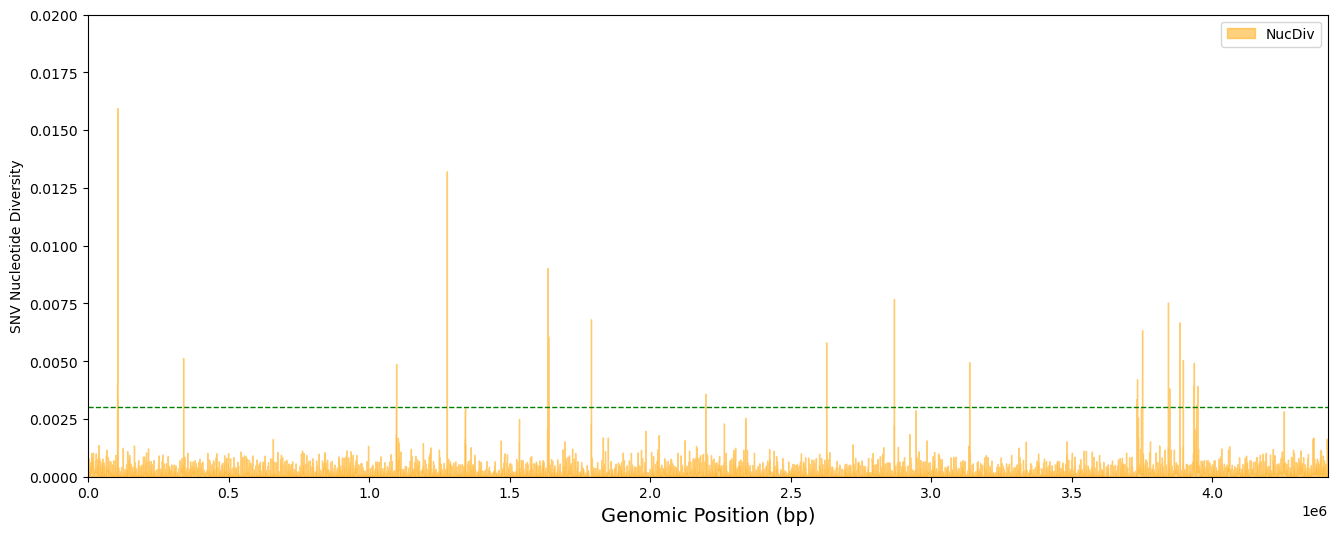

In [76]:
fig, axs = plt.subplots(1, 1, figsize=(16, 6), sharex=True)

xx_1kb_All_np, yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"], NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"]

axs.fill_between(xx_1kb_All_np, yy_1kb_All_np, alpha=0.5, color = "orange", label = "NucDiv",)
axs.hlines(y=0.003, xmin=0, xmax=5000000, linewidth=1, color='g', linestyles="--")
axs.set_xlabel('Genomic Position (bp)', fontsize = 14)
axs.set_ylabel('SNV Nucleotide Diversity', fontsize = 10)
axs.set_ylim(0, 0.020)
plt.xlim(0, 4412000)
axs.legend(loc="upper right")
       
plt.show()

In [77]:
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [78]:
NucDiv_PI_Dict[('ALL', 1000)]["DF"].head(6)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False
2,NC_000962.3,2000,3000,0.000306,dnaN,2500.0,0.305560,-0.024519,0.555218,False
3,NC_000962.3,3000,4000,0.000221,"dnaN,recF",3500.0,0.221073,-0.173203,0.143308,False
4,NC_000962.3,4000,5000,0.000222,"recF,Rv0004",4500.0,0.222481,-0.170725,0.150173,False
5,NC_000962.3,5000,6000,0.000079,gyrB,5500.0,0.079030,-0.423176,-0.549210,False


In [79]:
NucDiv_PI_Dict[('ALL', 1000)]["DF"].tail(15)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot
4406,NC_000962.3,4406000,4407000,0.000066,"parB,parA",4406500.0,0.066005,-0.446098,-0.612713,False
4407,NC_000962.3,4407000,4408000,0.001640,"parA,gid",4407500.0,1.639920,2.323749,7.060786,False
4408,NC_000962.3,4408000,4409000,0.001200,"gid,Rv3920c,Rv3921c",4408500.0,1.199530,1.548731,4.913699,False
4409,NC_000962.3,4409000,4410000,0.000182,Rv3921c,4409500.0,0.181998,-0.241969,-0.047199,False
4410,NC_000962.3,4410000,4411000,0.000232,"Rv3921c,Rv3922c,rnpA,rpmH",4410500.0,0.232338,-0.153378,0.198230,False
4411,NC_000962.3,4411000,4412000,0.000431,_,4411500.0,0.430882,0.196029,1.166216,False
4412,NC_000962.3,4412000,4413000,0.000000,NaN,4412500.0,0.000000,-0.562257,-0.934516,False
4413,NC_000962.3,4413000,4414000,0.000000,NaN,4413500.0,0.000000,-0.562257,-0.934516,False
4414,NC_000962.3,4414000,4415000,0.000000,NaN,4414500.0,0.000000,-0.562257,-0.934516,False
4415,NC_000962.3,4415000,4416000,0.000000,NaN,4415500.0,0.000000,-0.562257,-0.934516,False


# 3) Visualization of NucDiv across the genome

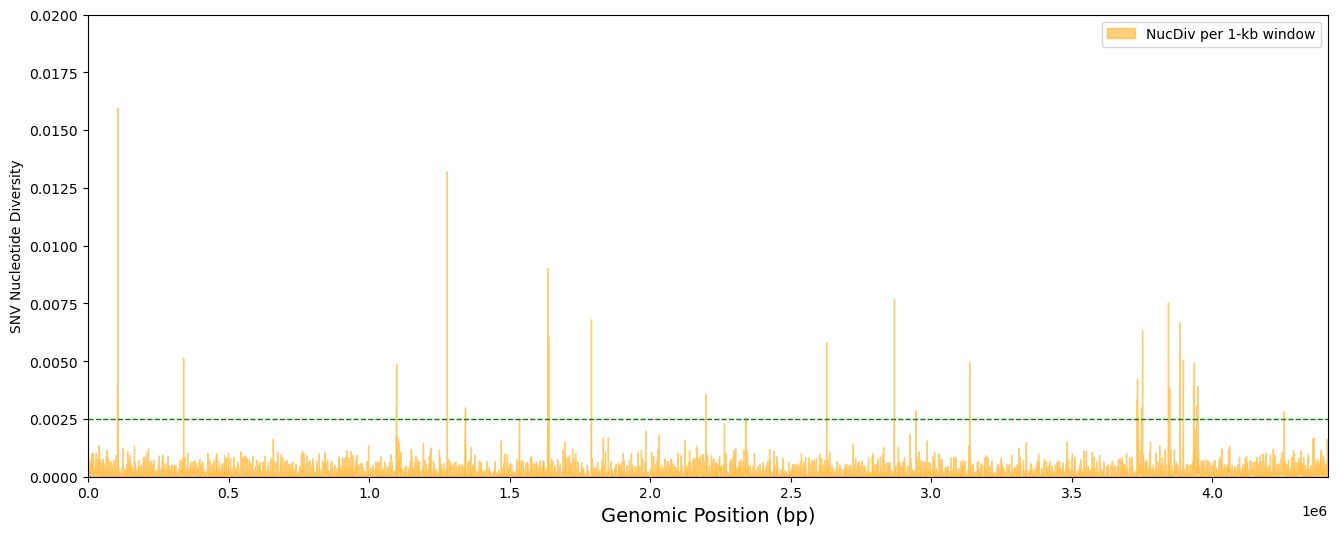

In [80]:
fig, axs = plt.subplots(1, 1, figsize=(16, 6), sharex=True)

xx_1kb_All_np, yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"], NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"]

axs.fill_between(xx_1kb_All_np, yy_1kb_All_np, alpha=0.5, color = "orange", label = "NucDiv per 1-kb window",)
axs.hlines(y=0.0025, xmin=0, xmax=5000000, linewidth=1, color='g', linestyles="--")
axs.set_xlabel('Genomic Position (bp)', fontsize = 14)
axs.set_ylabel('SNV Nucleotide Diversity', fontsize = 10)
axs.set_ylim(0, 0.020)
plt.xlim(0, 4412000)
axs.legend(loc="upper right")

#!mkdir ./NucDiv_Plots/
#plt.savefig(f"./NucDiv_Plots/WGA158CI.NucDiv_1kb_All_PB_003Thresh.png", dpi = 250)  
#plt.savefig(f"./NucDiv_Plots/WGA158CI.NucDiv_1kb_All_PB_003Thresh.pdf", transparent=True)               
plt.show()

In [81]:
NucDiv_PI_All_DF = NucDiv_PI_Dict[('ALL', 1000)]["DF"]
NucDiv_PI_All_DF.shape

(4421, 10)

In [82]:
NucDiv_PI_All_DF["NucDiv"].describe()

count    4421.000000
mean        0.000319
std         0.000568
min         0.000000
25%         0.000079
50%         0.000192
75%         0.000405
max         0.015961
Name: NucDiv, dtype: float64

In [83]:
NucDiv_PI_All_DF["NucDiv"].median()

0.000191679

In [84]:
NucDiv_PI_All_DF.query("NucDiv > 0.0025").shape

(34, 10)

In [85]:
NucDiv_PI_All_DF.query("NucDiv > 0.0020").shape

(41, 10)

In [86]:
NucDiv_PI_All_DF.query("NucDiv > 0.0020").head()

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True
1095,NC_000962.3,1095000,1096000,0.003100,"rpmF,PE_PGRS18",1095500.0,3.10016,4.893546,14.180072,True


## Plot NucDiv (SNPs/kb for each 1kb window)

In [87]:
WGA_NucDiv_PI_1kb_DF = NucDiv_PI_All_DF

# # Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv_kb'].median()
mean_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv_kb'].mean()
std_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv_kb'].std()
MAD_1kb_PI = np.median(np.abs(WGA_NucDiv_PI_1kb_DF['NucDiv_kb'] - median_1kb_PI))

# # Define outliers using modified Z-score procedure (Uses median instead of mean to ID outliers)

WGA_NucDiv_PI_1kb_DF['NucDiv_ModZ'] = 0.6745 * (WGA_NucDiv_PI_1kb_DF['NucDiv_kb'] - median_1kb_PI) / MAD_1kb_PI
WGA_NucDiv_PI_1kb_DF['IsNucDivHotspot'] = np.where(WGA_NucDiv_PI_1kb_DF['NucDiv_ModZ'] > 10, True, False)


In [88]:
ModZ_10_NucDiv = (10 / 0.6745) * MAD_1kb_PI + median_1kb_PI
ModZ_10_NucDiv

2.2427835218680507

In [89]:
median_1kb_PI * 1000

191.679

In [90]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

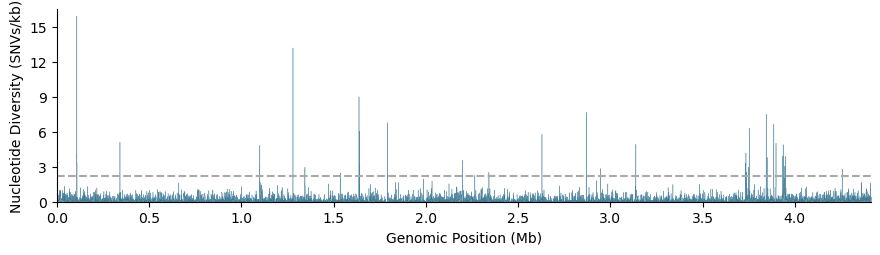

In [92]:
fig, axs = plt.subplots(1, 1, figsize=(10.5, 2.5), sharex=True)

xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000

axs.fill_between(xx_1kb_All_np, yy_1kb_All_np, color = '#065275', lw=0.3, alpha = 0.6)
axs.hlines(y= ModZ_10_NucDiv, xmin=0, xmax=5000000, color = "darkgrey", linewidth=1.5,  linestyles="--")
axs.set_xlabel('Genomic Position (Mb)', )#fontsize = 14)
axs.set_ylabel('Nucleotide Diversity (SNVs/kb)',) # fontsize = 10)
axs.set_ylim(0, 16.5)
plt.xlim(0, 4412000)

# Apply the custom formatter to the x-axis
axs.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

# Set specific tick positions and labels on the y-axis
tick_positions_y = [0, 3, 6, 9, 12, 15]
axs.set_yticks(tick_positions_y)
axs.set_yticklabels([str(tick) for tick in tick_positions_y])

sns.despine()
plt.show()


# Extras

In [ ]:
STOP!

In [87]:
import bioframe as bf

In [89]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2


In [90]:
NucDiv_PI_All_DF.head(3)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False
2,NC_000962.3,2000,3000,0.000306,dnaN,2500.0,0.305560,-0.024519,0.555218,False


In [92]:
# https://stackoverflow.com/questions/61109186/python-pandas-to-match-rows-with-overlapping-coordinates

listOf_Overlap_Genes = []
listOf_Overlap_Genes_RvIDs = []

for i, row in NucDiv_PI_All_DF.iterrows():
    
    # a) Target overlapping genes to event
    event_Start = int(row["Start"])
    event_End = int(row["End"])
    event_Range = f"NC_000962.3:{event_Start}-{event_End}"
    
    sub_DF_Overlap_HmRegions = bf.select(HmMapRegs_ParaRegs_k19w19_DF,
                                         event_Range, cols = ("Chr", "Start", "End"))    
    
    listOf_Overlap_Genes.append( ",".join(list(sub_DF_Overlap_HmRegions["HmRegionID"].values)) )

NucDiv_PI_All_DF["Overlap_HmRegions"] = listOf_Overlap_Genes

In [93]:
NucDiv_PI_All_DF.head(3)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,Overlap_HmRegions
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,
2,NC_000962.3,2000,3000,0.000306,dnaN,2500.0,0.305560,-0.024519,0.555218,False,


In [94]:
NucDiv_PI_All_DF.query("NucDiv > 0.0025").shape

(34, 11)

In [95]:
NucDiv_PI_All_DF.query("NucDiv > 0.0025").query("Overlap_HmRegions != ''").shape

(34, 11)

In [96]:
NucDiv_PI_All_DF.query("NucDiv > 0.0025").query("Overlap_HmRegions == ''").shape

(0, 11)

# 4) Lineage-level comparison

In [97]:
WGA151CI_AsmSummary_DF.head()

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
0,N0072,1,358,lineage1,"lineage1,lineage1.1,lineage1.1.2",ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon
1,N0153,1,372,lineage1,"lineage1,lineage1.1,lineage1.1.1,lineage1.1.1.1",ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon
2,TB3113,1,933,lineage2,"lineage2,lineage2.2,lineage2.2.1",TB_Portals_24CI_R1,PBrs2_LR_Flye_I3_SR_Pilon
3,TB1236,1,374,lineage2,"lineage2,lineage2.2,lineage2.2.1",TB_Portals_24CI_R1,PBrs2_LR_Flye_I3_SR_Pilon
4,TB2659,1,421,lineage2,"lineage2,lineage2.2,lineage2.2.1",TB_Portals_24CI_R1,PBrs2_LR_Flye_I3_SR_Pilon


In [98]:
#STOP!!!

# Let's parse NucDiv by Lineage across the MTBC

In [99]:
WGA151CI_AsmSummary_DF.head(3)

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
0,N0072,1,358,lineage1,"lineage1,lineage1.1,lineage1.1.2",ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon
1,N0153,1,372,lineage1,"lineage1,lineage1.1,lineage1.1.1,lineage1.1.1.1",ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon
2,TB3113,1,933,lineage2,"lineage2,lineage2.2,lineage2.2.1",TB_Portals_24CI_R1,PBrs2_LR_Flye_I3_SR_Pilon


In [100]:
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)


## A) Create Dict of sampleIDs for each lineage

In [101]:
DF_SampleID_And_Lineage = WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']]

Lin1_SampleIDs = list(DF_SampleID_And_Lineage[DF_SampleID_And_Lineage["PrimaryLineage"] == "lineage1"]["SampleID"].values )
Lin2_SampleIDs = list(DF_SampleID_And_Lineage[DF_SampleID_And_Lineage["PrimaryLineage"] == "lineage2"]["SampleID"].values )
Lin3_SampleIDs = list(DF_SampleID_And_Lineage[DF_SampleID_And_Lineage["PrimaryLineage"] == "lineage3"]["SampleID"].values )
Lin4_SampleIDs = list(DF_SampleID_And_Lineage[DF_SampleID_And_Lineage["PrimaryLineage"] == "lineage4"]["SampleID"].values )
Lin5_SampleIDs = list(DF_SampleID_And_Lineage[DF_SampleID_And_Lineage["PrimaryLineage"] == "lineage5"]["SampleID"].values )
Lin6_SampleIDs = list(DF_SampleID_And_Lineage[DF_SampleID_And_Lineage["PrimaryLineage"] == "lineage6"]["SampleID"].values )
Lin8_SampleIDs = list(DF_SampleID_And_Lineage[DF_SampleID_And_Lineage["PrimaryLineage"] == "lineage8"]["SampleID"].values )


In [102]:
WGA151CI_AsmSummary_DF["PrimaryLineage"].value_counts()

PrimaryLineage
lineage4    62
lineage2    61
lineage1    15
lineage3     7
lineage6     3
lineage5     2
lineage8     1
Name: count, dtype: int64

In [103]:
sorted(list(set(list(DF_SampleID_And_Lineage["PrimaryLineage"].values))))

['lineage1',
 'lineage2',
 'lineage3',
 'lineage4',
 'lineage5',
 'lineage6',
 'lineage8']

In [104]:
i_SampleToLin_DF = WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']]

listOfAllLineages = ['lineage1',
                     'lineage2',
                     'lineage3',
                     'lineage4', 'lineage5', 'lineage6', ]  #'lineage8'

LineageToSampleID_Dict = {}

for i_lineage in listOfAllLineages:
    
    i_SampleIDs_InLineage = list(i_SampleToLin_DF[i_SampleToLin_DF["PrimaryLineage"] == i_lineage]["SampleID"].values ) 
    
    LineageToSampleID_Dict[i_lineage] = i_SampleIDs_InLineage
    

## Run VCFtools-NucDiversity on samples of each lineage

In [105]:
lin1_SampleIDs = LineageToSampleID_Dict['lineage1']

lin1_SampleIDs_TEXT = ",".join(lin1_SampleIDs)

In [106]:
lin1_SampleIDs_TEXT

'N0072,N0153,mada_1-10,mada_2-46,mada_1-1,mada_1-36,mada_1-39,mada_1-51,mada_1-44,mada_117,mada_118,mada_122,mada_107,R27252,R23887'

In [107]:
print(Merged_VCF_SNVs_PATH)

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Asm_MergeVar_mpileup/MM2.mpileup.call.Merged.SNVs.vcf


In [108]:
PI_LinLevel_Dict = {}

for i_lineage in listOfAllLineages:

    Filter_Tag = "ALL"

    # Run VCFtools NucDiv calculation
    NucDiv_WindowSize = 1000

    VT_PI_Params_Tuple = (i_lineage, Filter_Tag, NucDiv_WindowSize)


    PI_LinLevel_Dict[ VT_PI_Params_Tuple] = {}
    PI_LinLevel_Dict[ VT_PI_Params_Tuple]["Fill_np"] = {}


    i_Lineage_Merged_VCF_SNVs_PATH = f"{Target_Output_Dir}/{AnalysisName}.MergedVCF.SNVs.{i_lineage}.vcf"

    
    i_Lineage_SampleIDs = LineageToSampleID_Dict[i_lineage]

    i_Lineage_SampleIDs_TEXT = ",".join(i_Lineage_SampleIDs)
    print(i_Lineage_SampleIDs_TEXT)

    !bcftools view -s $i_Lineage_SampleIDs_TEXT $Merged_VCF_SNVs_PATH > $i_Lineage_Merged_VCF_SNVs_PATH

    
    i_VCFT_NucDiv_PI_Output_Prefix = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.{NucDiv_WindowSize}bp.{Filter_Tag}.{i_lineage}"

    i_VCFT_NucDiv_PI_Output_Prefix_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.{NucDiv_WindowSize}bp.{Filter_Tag}.{i_lineage}.windowed.pi"

    !vcftools --vcf $i_Lineage_Merged_VCF_SNVs_PATH --window-pi $NucDiv_WindowSize --out $i_VCFT_NucDiv_PI_Output_Prefix

    # Parse

    i_VT_PI_TSV_DF = pd.read_csv(i_VCFT_NucDiv_PI_Output_Prefix_PATH, sep = "\t")
    i_VT_PI_TSV_DF["CenterOfRegion"] = ((i_VT_PI_TSV_DF["BIN_START"] + i_VT_PI_TSV_DF["BIN_END"] - 1) / 2)
    i_VT_PI_TSV_DF["BIN_START"] = i_VT_PI_TSV_DF["BIN_START"] - 1

    xx = []
    yy = []

    i_listOfTuples_NucDiv = []

    for i_start in (np.arange(0, 4420000 + NucDiv_WindowSize, NucDiv_WindowSize) ):

        i_end = i_start + NucDiv_WindowSize
        i_PI_Series = i_VT_PI_TSV_DF.query(f"(BIN_START == {i_start}) & (BIN_END == {i_end})")["PI"]

        if len(i_PI_Series) == 1: i_PI = i_PI_Series.values[0] 

        elif len(i_PI_Series) == 0: i_PI = 0

        i_row = ("NC_000962.3", i_start, i_end, i_PI)    
        i_listOfTuples_NucDiv.append(i_row)

        xx.append(i_start)
        xx.append(i_end)
        yy.append(i_PI)
        yy.append(i_PI)


    # Create NP arrays for visualization of results using the fill_between function of matplotlib
    i_X_GenomicPos_np = np.array(xx)
    i_Y_NucDiv_np = np.array(yy)

    PI_LinLevel_Dict[VT_PI_Params_Tuple]["Fill_np"]["XX"] = i_X_GenomicPos_np
    PI_LinLevel_Dict[VT_PI_Params_Tuple]["Fill_np"]["YY"] = i_Y_NucDiv_np


    # Create dataframe and TSV for parsing of results:
    i_PI_DF = pd.DataFrame(i_listOfTuples_NucDiv)
    i_PI_DF.columns = ["Chrom", "Start", "End", "NucDiv"]
    i_PI_DF["OverlapGenes"] = i_PI_DF["Start"].map(Rv_1kb_Window_Start_To_Genes_Dict)
    i_PI_DF["Middle"] = (i_PI_DF["Start"] + i_PI_DF["End"]) / 2

    PI_LinLevel_Dict[VT_PI_Params_Tuple]["DF"] = i_PI_DF

    i_NucDiv_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.{NucDiv_WindowSize}bp.{Filter_Tag}.{i_lineage}.tsv"

    i_PI_DF.to_csv(i_NucDiv_TSV_PATH, sep = "\t", index=False)

N0072,N0153,mada_1-10,mada_2-46,mada_1-1,mada_1-36,mada_1-39,mada_1-51,mada_1-44,mada_117,mada_118,mada_122,mada_107,R27252,R23887

VCFtools - 0.1.16
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/250201.WGA151CI.V10.MergedVCF.SNVs.lineage1.vcf
	--out /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/VCFtools_SNV_NucDiv_AcrossH37Rv/WGA.SNVs.NucDiv.1000bp.ALL.lineage1
	--window-pi 1000

After filtering, kept 15 out of 15 Individuals
Outputting Windowed Nucleotide Diversity Statistics...
After filtering, kept 24068 out of a possible 24068 Sites
Run Time = 1.00 seconds
TB3113,TB1236,TB2659,TB2780,TB1612,TB2512,TB2981,TB3091,M0003941_3,TB3368,N0145,N0155,TB2995,TB3396,9050-05,4549-04,696-05,702-06,706-05,8129-04,3003-06,8651-04,R30215,R30078,R29816,R30234,18_0621851,R36431,R28703,mada_115,mada_2-42,R31095,R28012,R37765,R27657,R25048,R24120,R28581,R29

In [109]:
i_PI_DF.head()

,Chrom,Start,End,NucDiv,OverlapGenes,Middle
0,NC_000962.3,0,1000,0.000533,dnaA,500.0
1,NC_000962.3,1000,2000,0.000000,dnaA,1500.0
2,NC_000962.3,2000,3000,0.000000,dnaN,2500.0
3,NC_000962.3,3000,4000,0.000000,"dnaN,recF",3500.0
4,NC_000962.3,4000,5000,0.001067,"recF,Rv0004",4500.0


### Output Lineage level NucDiversity info as PICKLE

In [110]:

Pickle_PATH_NucDIv_PI_LinLevel_Dict = VCFT_NucDiv_Dir + "/WGA.SNVs.NucDiv.LineageLevel.DictOfResults.pickle"   

with open(Pickle_PATH_NucDIv_PI_LinLevel_Dict, 'wb') as outputFile:
    pickle.dump(PI_LinLevel_Dict, outputFile)
    


In [111]:
PI_LinLevel_Dict[(i_lineage, 'ALL', 1000)]

{'Fill_np': {'XX': array([      0,    1000,    1000, ..., 4420000, 4420000, 4421000]),
  'YY': array([0.00053333, 0.00053333, 0.        , ..., 0.        , 0.        ,
         0.        ])},
 'DF':             Chrom    Start      End    NucDiv OverlapGenes     Middle
 0     NC_000962.3        0     1000  0.000533         dnaA      500.0
 1     NC_000962.3     1000     2000  0.000000         dnaA     1500.0
 2     NC_000962.3     2000     3000  0.000000         dnaN     2500.0
 3     NC_000962.3     3000     4000  0.000000    dnaN,recF     3500.0
 4     NC_000962.3     4000     5000  0.001067  recF,Rv0004     4500.0
 ...           ...      ...      ...       ...          ...        ...
 4416  NC_000962.3  4416000  4417000  0.000000          NaN  4416500.0
 4417  NC_000962.3  4417000  4418000  0.000000          NaN  4417500.0
 4418  NC_000962.3  4418000  4419000  0.000000          NaN  4418500.0
 4419  NC_000962.3  4419000  4420000  0.000000          NaN  4419500.0
 4420  NC_000962.3  44

## Create Lineage-level NucDiv DF

In [112]:
PI_LinComp_DF = PI_LinLevel_Dict[(i_lineage, 'ALL', 1000)]["DF"].drop("NucDiv", axis = 1)

PI_LinComp_DF["NucDiv_L1"] = PI_LinLevel_Dict[('lineage1', 'ALL', 1000)]["DF"]["NucDiv"]
PI_LinComp_DF["NucDiv_L2"] = PI_LinLevel_Dict[('lineage2', 'ALL', 1000)]["DF"]["NucDiv"]
PI_LinComp_DF["NucDiv_L3"] = PI_LinLevel_Dict[('lineage3', 'ALL', 1000)]["DF"]["NucDiv"]
PI_LinComp_DF["NucDiv_L4"] = PI_LinLevel_Dict[('lineage4', 'ALL', 1000)]["DF"]["NucDiv"]
PI_LinComp_DF.shape

(4421, 9)

# Visualize Lineage-level differences in NucDiversity

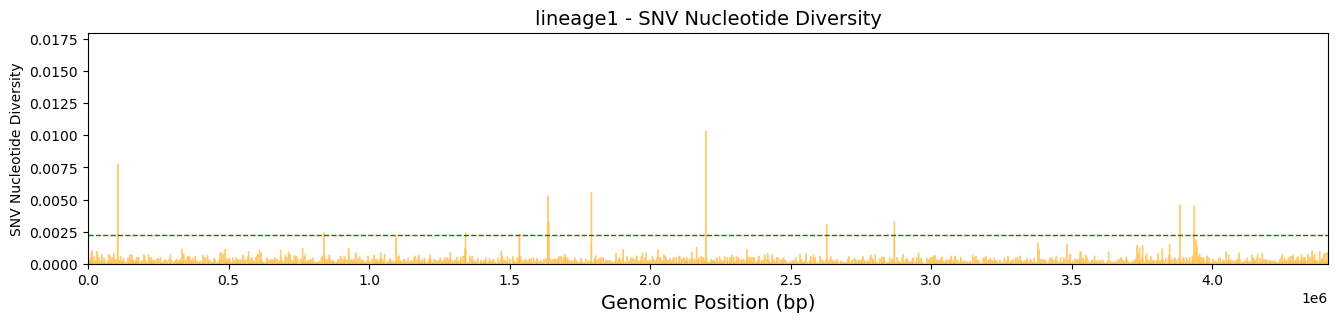

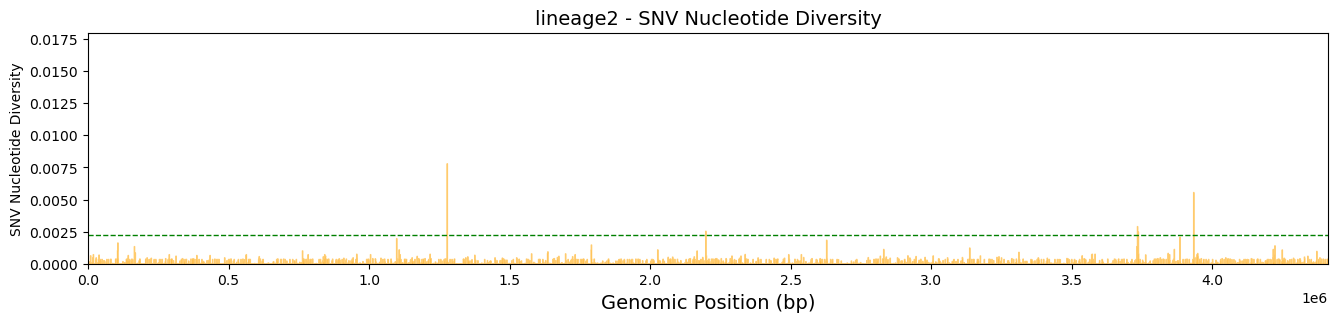

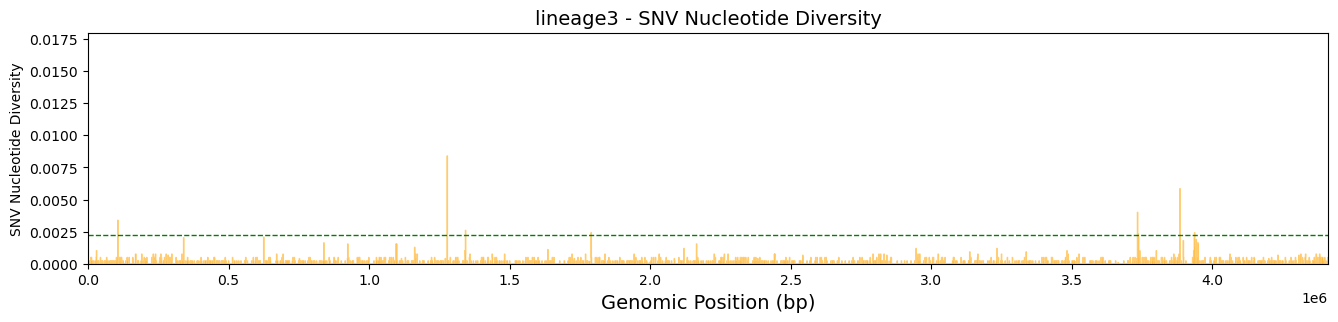

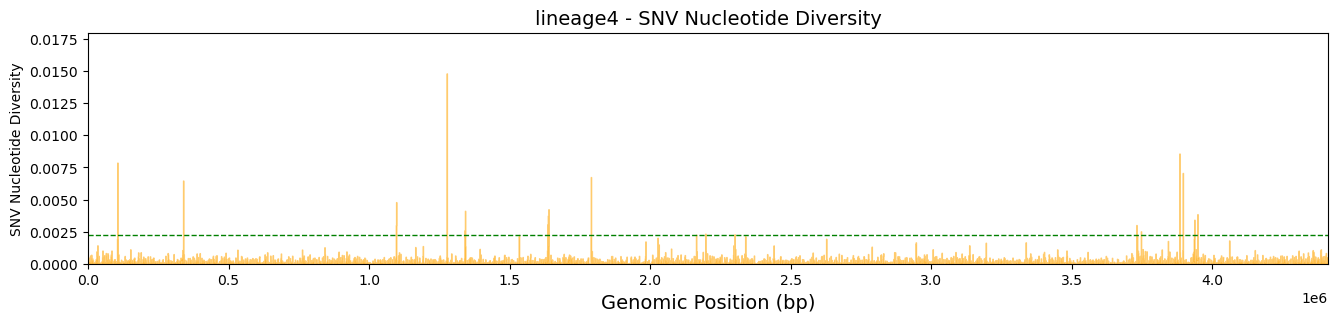

In [113]:
for i_lineage in ["lineage1", "lineage2", "lineage3", "lineage4",]: #listOfAllLineages:

    fig, axs = plt.subplots(1, 1, figsize=(16, 3), sharex=True)

    xx_1kb_All_np, yy_1kb_All_np = PI_LinLevel_Dict[(i_lineage, 'ALL', 1000)]["Fill_np"]["XX"], PI_LinLevel_Dict[(i_lineage, 'ALL', 1000)]["Fill_np"]["YY"]

    axs.fill_between(xx_1kb_All_np, yy_1kb_All_np, alpha=0.5, color = "orange", label = "Complete diversity observable w/ PacBio sequencing",)

    axs.hlines(y=0.0022427835218680504, xmin=0, xmax=5000000, linewidth=1, color='g', linestyles="--")
    
    axs.set_xlabel('Genomic Position (bp)', fontsize = 14)
    axs.set_ylabel('SNV Nucleotide Diversity', fontsize = 10)
    axs.set_title(f'{i_lineage} - SNV Nucleotide Diversity', fontsize = 14)

    axs.set_ylim(0, 0.018)
    plt.xlim(0, 4412000)
               
    plt.show()


In [114]:
PI_LinComp_DF.query("NucDiv_L1 >= 0.0025").query("NucDiv_L1 >= NucDiv_L4")

,Chrom,Start,End,OverlapGenes,Middle,NucDiv_L1,NucDiv_L2,NucDiv_L3,NucDiv_L4
1633,NC_000962.3,1633000,1634000,PE_PGRS27,1633500.0,0.003255,0.000845,0.000000,0.001043
1634,NC_000962.3,1634000,1635000,PE_PGRS27,1634500.0,0.005297,0.000968,0.001143,0.003054
1637,NC_000962.3,1637000,1638000,PE_PGRS28,1637500.0,0.003310,0.000093,0.000000,0.001412
2196,NC_000962.3,2196000,2197000,Rv1945,2196500.0,0.010354,0.002570,0.000000,0.002340
2197,NC_000962.3,2197000,2198000,"Rv1945,lppG",2197500.0,0.002740,0.000254,0.000000,0.001040
2626,NC_000962.3,2626000,2627000,"esxO,esxP,Rv2348c",2626500.0,0.003108,0.001870,0.000000,0.001943
2867,NC_000962.3,2867000,2868000,"lppA,lppB,vapB18",2867500.0,0.003292,0.000000,0.000000,0.000192
3934,NC_000962.3,3934000,3935000,PE_PGRS54,3934500.0,0.004553,0.000093,0.002025,0.001916


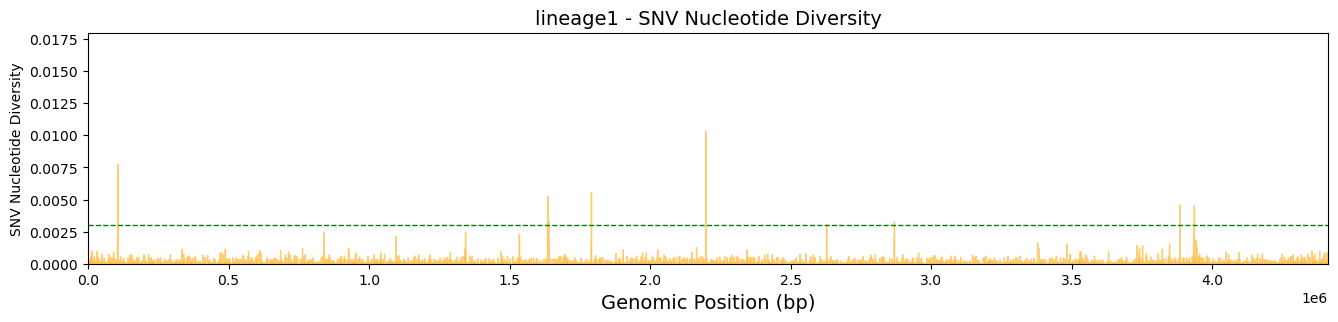

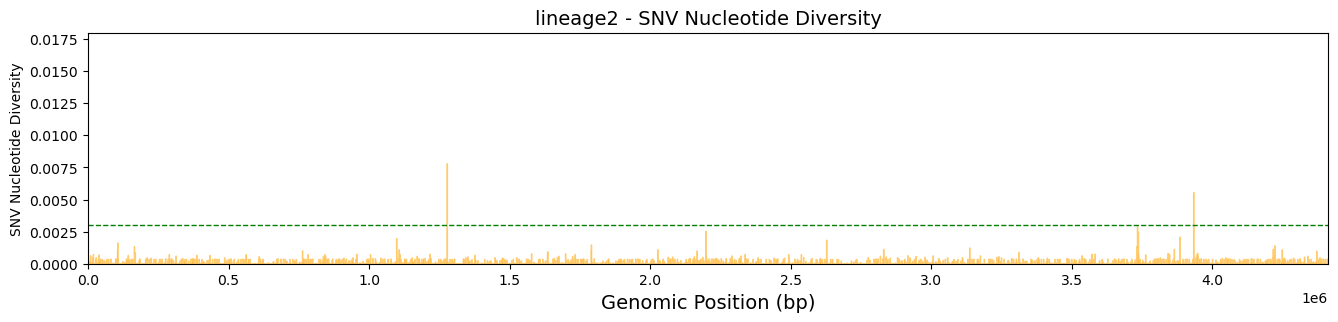

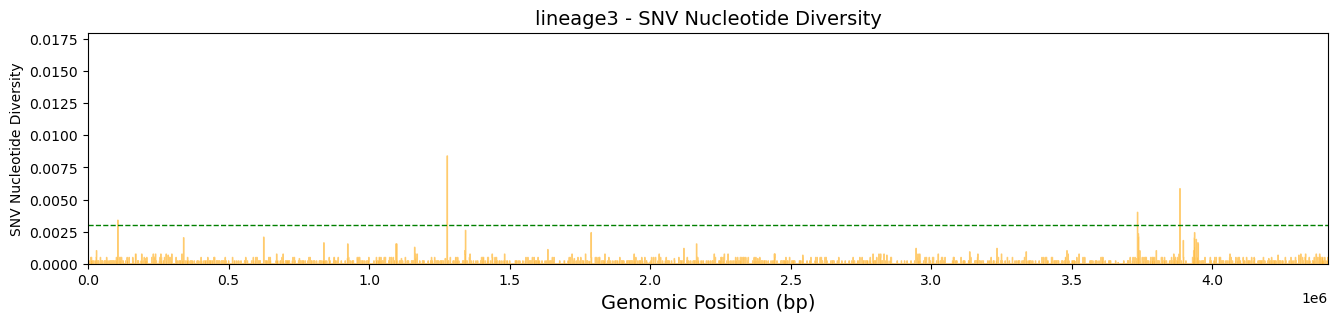

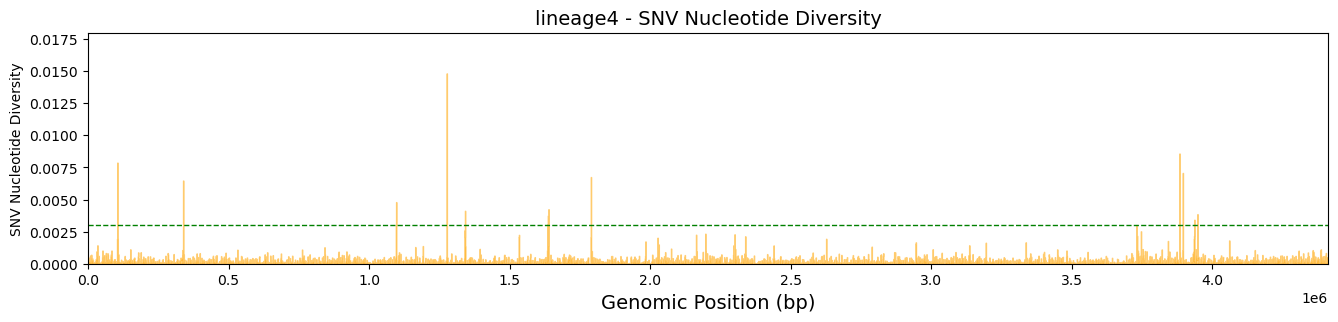

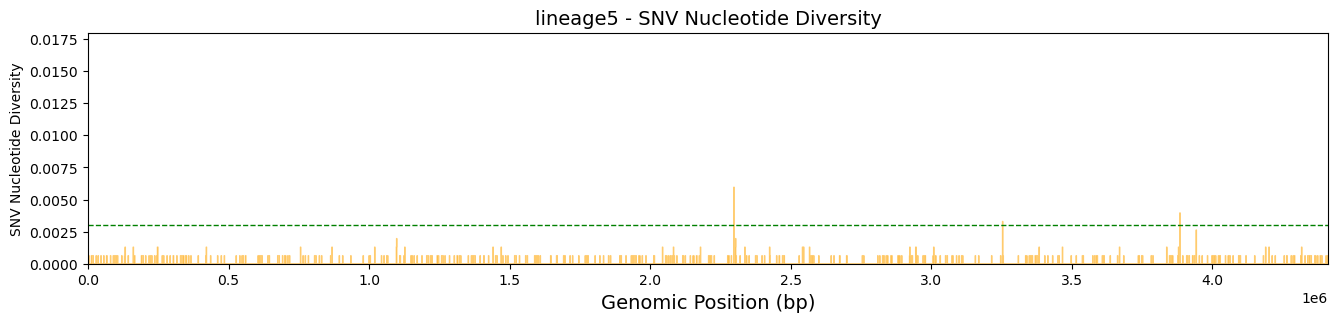

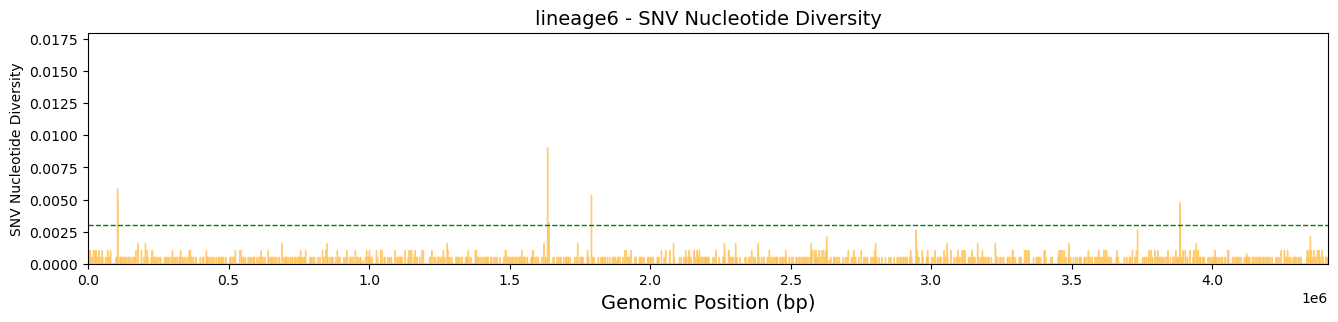

In [115]:
for i_lineage in ["lineage1", "lineage2", "lineage3", "lineage4", 'lineage5', 'lineage6']: #listOfAllLineages:

    fig, axs = plt.subplots(1, 1, figsize=(16, 3), sharex=True)

    xx_1kb_All_np, yy_1kb_All_np = PI_LinLevel_Dict[(i_lineage, 'ALL', 1000)]["Fill_np"]["XX"], PI_LinLevel_Dict[(i_lineage, 'ALL', 1000)]["Fill_np"]["YY"]

    axs.fill_between(xx_1kb_All_np, yy_1kb_All_np, alpha=0.5, color = "orange", label = "Complete diversity observable w/ PacBio sequencing",)
    axs.hlines(y=0.003, xmin=0, xmax=5000000, linewidth=1, color='g', linestyles="--")
    axs.set_xlabel('Genomic Position (bp)', fontsize = 14)
    axs.set_ylabel('SNV Nucleotide Diversity', fontsize = 10)
    axs.set_title(f'{i_lineage} - SNV Nucleotide Diversity', fontsize = 14)

    axs.set_ylim(0, 0.018)
    plt.xlim(0, 4412000)
               
    plt.show()


In [116]:
PI_LinLevel_Dict[(i_lineage, 'ALL', 1000)]["DF"].query("NucDiv >= 0.0025")

,Chrom,Start,End,NucDiv,OverlapGenes,Middle
103,NC_000962.3,103000,104000,0.005867,"Rv0093c,Rv0094c",103500.0
104,NC_000962.3,104000,105000,0.004800,"Rv0094c,Rv0095c",104500.0
1633,NC_000962.3,1633000,1634000,0.009067,PE_PGRS27,1633500.0
1637,NC_000962.3,1637000,1638000,0.002667,PE_PGRS28,1637500.0
1638,NC_000962.3,1638000,1639000,0.003200,"PE_PGRS28,Rv1453",1638500.0
1789,NC_000962.3,1789000,1790000,0.005333,"Rv1587c,Rv1588c",1789500.0
2944,NC_000962.3,2944000,2945000,0.002667,PE_PGRS45,2944500.0
3732,NC_000962.3,3732000,3733000,0.002667,PPE54,3732500.0
3883,NC_000962.3,3883000,3884000,0.004800,"rmlC,Rv3466,Rv3467",3883500.0
3884,NC_000962.3,3884000,3885000,0.003733,"Rv3466,Rv3467,Rv3468c",3884500.0
